In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Riyansh Jain\OneDrive\Desktop\kestrel-home-returns-risk\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
# Project root
PROJECT_ROOT = Path.cwd().parent

# Data directory
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: c:\Users\Riyansh Jain\OneDrive\Desktop\kestrel-home-returns-risk
Data directory: c:\Users\Riyansh Jain\OneDrive\Desktop\kestrel-home-returns-risk\data


In [4]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test_unlabelled.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")


In [5]:

print("Train:", train.shape)
print("Test:", test.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sample submission:", sample_submission.shape)

Train: (11155, 19)
Test: (2096, 18)
Customers: (9000, 5)
Products: (21, 6)
Sample submission: (2096, 2)


In [6]:
for i, col in enumerate(train.columns, start=1):
    print(f"{i:2}. {col}")
    

 1. order_id
 2. order_placed_at
 3. customer_id
 4. sku
 5. sales_channel
 6. payment_mode
 7. discount_pct
 8. qty
 9. order_value_inr
10. promised_delivery_days
11. delivery_pincode
12. is_gift
13. customer_prior_orders
14. customer_prior_returns
15. delivery_note
16. last_service_event_type
17. pickup_scheduled_at
18. source
19. returned


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11155 entries, 0 to 11154
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 11155 non-null  str    
 1   order_placed_at          11155 non-null  str    
 2   customer_id              11155 non-null  str    
 3   sku                      11155 non-null  str    
 4   sales_channel            11155 non-null  str    
 5   payment_mode             11155 non-null  str    
 6   discount_pct             11155 non-null  int64  
 7   qty                      11155 non-null  int64  
 8   order_value_inr          11155 non-null  float64
 9   promised_delivery_days   11155 non-null  int64  
 10  delivery_pincode         11155 non-null  int64  
 11  is_gift                  11155 non-null  str    
 12  customer_prior_orders    11155 non-null  int64  
 13  customer_prior_returns   11155 non-null  int64  
 14  delivery_note            8403 non

In [8]:
train["returned"].value_counts()

returned
0    9888
1    1267
Name: count, dtype: int64

In [9]:
train["returned"].value_counts(normalize=True)

returned
0    0.886419
1    0.113581
Name: proportion, dtype: float64

In [10]:
missing = (
    train.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

pickup_scheduled_at    9855
delivery_note          2752
dtype: int64

In [11]:
print("Total rows:", len(train))
print("Unique order IDs:", train["order_id"].nunique())
print("Duplicate rows by order_id:", train["order_id"].duplicated().sum())

Total rows: 11155
Unique order IDs: 10504
Duplicate rows by order_id: 651


In [12]:
duplicate_orders = (
    train[train["order_id"].duplicated(keep=False)]
    .sort_values("order_id")
)

duplicate_orders[[
    "order_id",
    "source",
    "returned"
]].head(20)

,order_id,source,returned
13,KO2600013,partner_feed,0
14,KO2600013,crm,0
34,KO2600033,crm,0
35,KO2600033,partner_feed,0
47,KO2600045,crm,0
48,KO2600045,partner_feed,0
53,KO2600050,crm,0
54,KO2600050,partner_feed,0
64,KO2600060,crm,0
65,KO2600060,partner_feed,0


In [13]:
duplicate_summary = (
    train.groupby("order_id")
    .agg(
        row_count=("order_id", "size"),
        unique_sources=("source", "nunique"),
        unique_return_labels=("returned", "nunique")
    )
)

duplicate_summary.head(20)

,row_count,unique_sources,unique_return_labels
order_id,,,
KO2600000,1,1,1
KO2600001,1,1,1
KO2600002,1,1,1
KO2600003,1,1,1
KO2600004,1,1,1
KO2600005,1,1,1
KO2600006,1,1,1
KO2600007,1,1,1
KO2600008,1,1,1


In [14]:
conflicting_orders = duplicate_summary[
    duplicate_summary["unique_return_labels"] > 1
]

print("Duplicate order IDs:", (duplicate_summary["row_count"] > 1).sum())
print("Conflicting duplicate labels:", len(conflicting_orders))

Duplicate order IDs: 651
Conflicting duplicate labels: 0


In [15]:
source_return_rate = (
    train.groupby("source")["returned"]
    .agg(
        orders="count",
        return_rate="mean"
    )
)

source_return_rate

,orders,return_rate
source,,
crm,10504,0.114242
partner_feed,651,0.102919


In [16]:
duplicate_ids = duplicate_summary[
    duplicate_summary["row_count"] > 1
].index

duplicate_data = (
    train[train["order_id"].isin(duplicate_ids)]
    .sort_values(["order_id", "source"])
)

duplicate_data.head(10)

,order_id,order_placed_at,customer_id,sku,sales_channel,payment_mode,discount_pct,qty,order_value_inr,promised_delivery_days,delivery_pincode,is_gift,customer_prior_orders,customer_prior_returns,delivery_note,last_service_event_type,pickup_scheduled_at,source,returned
14,KO2600013,2025-04-01 13:54,KC103076,KH-AF-03,partner_outlet,prepaid_upi,1,1,8685.27,10,440254,N,3,0,Landmark: opposite HP petrol pump,NONE,NaN,crm,0
13,KO2600013,2025-04-01 13:54,KC103076,KH-AF-03,partner_outlet,prepaid_upi,1,1,8685.27,10,440254,N,3,0,Landmark: opposite HP petrol pump,NONE,NaN,partner_feed,0
34,KO2600033,2025-04-02 10:09,KC104352,KH-MG-01,partner_outlet,prepaid_card,7,1,2975.07,3,400562,N,1,0,NaN,NONE,NaN,crm,0
35,KO2600033,2025-04-02 10:09,KC104352,KH-MG-01,partner_outlet,prepaid_card,7,1,2975.07,3,400562,N,1,0,NaN,NONE,NaN,partner_feed,0
47,KO2600045,2025-04-03 01:54,KC101671,KH-AF-03,partner_outlet,prepaid_upi,13,1,7632.51,5,500333,N,1,0,Landmark: opposite St. Mary's school,NONE,NaN,crm,0
48,KO2600045,2025-04-03 01:54,KC101671,KH-AF-03,partner_outlet,prepaid_upi,13,1,7632.51,5,500333,N,1,0,Landmark: opposite St. Mary's school,NONE,NaN,partner_feed,0
53,KO2600050,2025-04-03 05:31,KC102336,KH-AF-03,partner_outlet,emi,6,1,8246.62,10,440671,N,0,0,NaN,NONE,NaN,crm,0
54,KO2600050,2025-04-03 05:31,KC102336,KH-AF-03,partner_outlet,emi,6,1,8246.62,10,440671,N,0,0,NaN,NONE,NaN,partner_feed,0
64,KO2600060,2025-04-03 19:02,KC102065,KH-AF-03,partner_outlet,cod,6,1,8246.62,4,440233,N,1,0,"Do not call, WhatsApp only",NONE,NaN,crm,0
65,KO2600060,2025-04-03 19:02,KC102065,KH-AF-03,partner_outlet,cod,6,1,8246.62,4,440233,N,1,0,"Do not call, WhatsApp only",NONE,NaN,partner_feed,0


In [17]:
duplicate_data.groupby("order_id").size().value_counts()

2    651
Name: count, dtype: int64

In [18]:
duplicate_data[
    ["order_id", "source", "customer_id", "sku",
     "sales_channel", "payment_mode",
     "discount_pct", "qty", "order_value_inr",
     "promised_delivery_days", "returned"]
].head(20)

,order_id,source,customer_id,sku,sales_channel,payment_mode,discount_pct,qty,order_value_inr,promised_delivery_days,returned
14,KO2600013,crm,KC103076,KH-AF-03,partner_outlet,prepaid_upi,1,1,8685.27,10,0
13,KO2600013,partner_feed,KC103076,KH-AF-03,partner_outlet,prepaid_upi,1,1,8685.27,10,0
34,KO2600033,crm,KC104352,KH-MG-01,partner_outlet,prepaid_card,7,1,2975.07,3,0
35,KO2600033,partner_feed,KC104352,KH-MG-01,partner_outlet,prepaid_card,7,1,2975.07,3,0
47,KO2600045,crm,KC101671,KH-AF-03,partner_outlet,prepaid_upi,13,1,7632.51,5,0
48,KO2600045,partner_feed,KC101671,KH-AF-03,partner_outlet,prepaid_upi,13,1,7632.51,5,0
53,KO2600050,crm,KC102336,KH-AF-03,partner_outlet,emi,6,1,8246.62,10,0
54,KO2600050,partner_feed,KC102336,KH-AF-03,partner_outlet,emi,6,1,8246.62,10,0
64,KO2600060,crm,KC102065,KH-AF-03,partner_outlet,cod,6,1,8246.62,4,0
65,KO2600060,partner_feed,KC102065,KH-AF-03,partner_outlet,cod,6,1,8246.62,4,0


In [19]:
train["order_placed_at"] = pd.to_datetime(train["order_placed_at"])
test["order_placed_at"] = pd.to_datetime(test["order_placed_at"])

print("TRAIN DATE RANGE")
print("Start:", train["order_placed_at"].min())
print("End:", train["order_placed_at"].max())

print("\nTEST DATE RANGE")
print("Start:", test["order_placed_at"].min())
print("End:", test["order_placed_at"].max())

TRAIN DATE RANGE
Start: 2025-04-01 00:22:00
End: 2026-06-30 23:08:00

TEST DATE RANGE
Start: 2026-07-01 00:51:00
End: 2026-09-30 23:46:00


In [20]:
print("Train rows:", len(train))
print("Test rows:", len(test))

print("\nTrain months:")
print(train["order_placed_at"].dt.to_period("M").value_counts().sort_index())

print("\nTest months:")
print(test["order_placed_at"].dt.to_period("M").value_counts().sort_index())

Train rows: 11155
Test rows: 2096

Train months:
order_placed_at
2025-04    698
2025-05    708
2025-06    721
2025-07    785
2025-08    759
2025-09    747
2025-10    748
2025-11    737
2025-12    723
2026-01    769
2026-02    710
2026-03    789
2026-04    760
2026-05    759
2026-06    742
Freq: M, Name: count, dtype: int64

Test months:
order_placed_at
2026-07    668
2026-08    733
2026-09    695
Freq: M, Name: count, dtype: int64


In [21]:
train_customer_missing = (
    ~train["customer_id"].isin(customers["customer_id"])
).sum()

test_customer_missing = (
    ~test["customer_id"].isin(customers["customer_id"])
).sum()

print("Train customer IDs missing from customers.csv:", train_customer_missing)
print("Test customer IDs missing from customers.csv:", test_customer_missing)

Train customer IDs missing from customers.csv: 0
Test customer IDs missing from customers.csv: 0


In [22]:
train_product_missing = (
    ~train["sku"].isin(products["sku"])
).sum()

test_product_missing = (
    ~test["sku"].isin(products["sku"])
).sum()

print("Train SKUs missing from products.csv:", train_product_missing)
print("Test SKUs missing from products.csv:", test_product_missing)

Train SKUs missing from products.csv: 0
Test SKUs missing from products.csv: 0


In [23]:
print("Duplicate customer IDs:", customers["customer_id"].duplicated().sum())
print("Duplicate SKUs:", products["sku"].duplicated().sum())

Duplicate customer IDs: 0
Duplicate SKUs: 0


In [24]:
print("Train columns not in test:")
print(set(train.columns) - set(test.columns))

print("\nTest columns not in train:")
print(set(test.columns) - set(train.columns))

Train columns not in test:
{'returned'}

Test columns not in train:
set()


In [25]:
categorical_cols = [
    "sales_channel",
    "payment_mode",
    "is_gift",
    "source"
]

for col in categorical_cols:
    train_values = set(train[col].dropna().unique())
    test_values = set(test[col].dropna().unique())

    unseen_in_train = test_values - train_values

    print(f"\n{col}")
    print("Train:", sorted(train_values))
    print("Test :", sorted(test_values))
    print("Unseen test values:", unseen_in_train)


sales_channel
Train: ['app', 'marketplace', 'partner_outlet', 'web']
Test : ['app', 'marketplace', 'partner_outlet', 'web']
Unseen test values: set()

payment_mode
Train: ['cod', 'emi', 'prepaid_card', 'prepaid_upi']
Test : ['cod', 'emi', 'prepaid_card', 'prepaid_upi']
Unseen test values: set()

is_gift
Train: ['N', 'Y']
Test : ['N', 'Y']
Unseen test values: set()

source
Train: ['crm', 'partner_feed']
Test : ['crm']
Unseen test values: set()


In [26]:
numeric_cols = [
    "discount_pct",
    "qty",
    "order_value_inr",
    "promised_delivery_days",
    "delivery_pincode",
    "customer_prior_orders",
    "customer_prior_returns"
]

comparison = pd.DataFrame({
    "train_min": train[numeric_cols].min(),
    "train_max": train[numeric_cols].max(),
    "test_min": test[numeric_cols].min(),
    "test_max": test[numeric_cols].max()
})

comparison

,train_min,train_max,test_min,test_max
discount_pct,0.00,60.0,0.00,51.00
qty,1.00,2.0,1.00,2.00
order_value_inr,1159.42,5880204.0,1367.43,57020.16
promised_delivery_days,1.00,12.0,1.00,12.00
delivery_pincode,0.00,600995.0,0.00,600995.00
customer_prior_orders,0.00,10.0,0.00,9.00
customer_prior_returns,0.00,6.0,0.00,5.00


In [27]:
print("Does test contain returned?", "returned" in test.columns)

Does test contain returned? False


In [28]:
for col in train.columns:
    print(f"{col:30} | dtype: {train[col].dtype}")

order_id                       | dtype: str
order_placed_at                | dtype: datetime64[us]
customer_id                    | dtype: str
sku                            | dtype: str
sales_channel                  | dtype: str
payment_mode                   | dtype: str
discount_pct                   | dtype: int64
qty                            | dtype: int64
order_value_inr                | dtype: float64
promised_delivery_days         | dtype: int64
delivery_pincode               | dtype: int64
is_gift                        | dtype: str
customer_prior_orders          | dtype: int64
customer_prior_returns         | dtype: int64
delivery_note                  | dtype: str
last_service_event_type        | dtype: str
pickup_scheduled_at            | dtype: str
source                         | dtype: str
returned                       | dtype: int64


In [29]:
leakage_check = pd.DataFrame({
    "feature": train.columns,
    "missing_count": train.isnull().sum().values,
    "missing_pct": (train.isnull().mean() * 100).round(2).values
})

leakage_check

,feature,missing_count,missing_pct
0,order_id,0,0.00
1,order_placed_at,0,0.00
2,customer_id,0,0.00
3,sku,0,0.00
4,sales_channel,0,0.00
5,payment_mode,0,0.00
6,discount_pct,0,0.00
7,qty,0,0.00
8,order_value_inr,0,0.00
9,promised_delivery_days,0,0.00


In [30]:
print("last_service_event_type:")
print(train["last_service_event_type"].value_counts(dropna=False))

print("\npickup_scheduled_at missing/non-missing:")
print(train["pickup_scheduled_at"].notna().value_counts())

last_service_event_type:
last_service_event_type
NONE              6946
DEMO_DONE         1507
INSTALL_DONE      1437
REVERSE_PICKUP     789
TECH_VISIT         476
Name: count, dtype: int64

pickup_scheduled_at missing/non-missing:
pickup_scheduled_at
False    9855
True     1300
Name: count, dtype: int64


In [31]:
service_return_analysis = (
    train.groupby("last_service_event_type")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
    .sort_values("return_rate", ascending=False)
)

service_return_analysis

,orders,returns,return_rate
last_service_event_type,,,
REVERSE_PICKUP,789,789,1.000000
TECH_VISIT,476,180,0.378151
NONE,6946,298,0.042902
DEMO_DONE,1507,0,0.000000
INSTALL_DONE,1437,0,0.000000


In [32]:
pickup_return_analysis = (
    train.assign(
        pickup_present=train["pickup_scheduled_at"].notna()
    )
    .groupby("pickup_present")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

pickup_return_analysis

,orders,returns,return_rate
pickup_present,,,
False,9855,76,0.007712
True,1300,1191,0.916154


In [93]:
## Leakage Audit

The prediction target is whether an order will be returned **before dispatch**.

Two operational fields were identified as unsafe for the final model:

### 1. `pickup_scheduled_at`

This field is populated as part of the reverse-pickup workflow. The operations policy states that after a return is approved, logistics books a reverse pickup and the service system records a `REVERSE_PICKUP` event.

The training data also provides strong empirical evidence of leakage:

- Orders without a pickup scheduled: 0.77% return rate
- Orders with a pickup scheduled: 91.62% return rate

Therefore, `pickup_scheduled_at` is excluded from the dispatch-time model.

### 2. `last_service_event_type`

This field is also excluded because it represents service-system state that is not guaranteed to be available at the moment of dispatch.

The strongest evidence is:

- `REVERSE_PICKUP`: 789 orders, 100% returned
- `TECH_VISIT`: 476 orders, 37.82% returned
- `NONE`: 6,946 orders, 4.29% returned

Using `REVERSE_PICKUP` would effectively reveal the outcome after the return process has already started.

### Final decision

The following fields are excluded from the final dispatch-time model:

- `pickup_scheduled_at`
- `last_service_event_type`

The model will only use information that can reasonably be available before dispatch.

SyntaxError: invalid syntax (3457105728.py, line 3)

In [33]:
return_rate_by_payment = (
    train.groupby("payment_mode")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
    .sort_values("return_rate", ascending=False)
)

return_rate_by_payment

,orders,returns,return_rate
payment_mode,,,
cod,3355,632,0.188376
emi,1360,122,0.089706
prepaid_card,2290,198,0.086463
prepaid_upi,4150,315,0.075904


In [34]:
return_rate_by_channel = (
    train.groupby("sales_channel")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
    .sort_values("return_rate", ascending=False)
)

return_rate_by_channel

,orders,returns,return_rate
sales_channel,,,
marketplace,2906,393,0.135237
web,2797,310,0.110833
app,3613,387,0.107113
partner_outlet,1839,177,0.096248


In [35]:
train_with_customers = train.merge(
    customers[["customer_id", "shield_member"]],
    on="customer_id",
    how="left"
)

shield_return_rate = (
    train_with_customers
    .groupby("shield_member")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
    .sort_values("return_rate", ascending=False)
)

shield_return_rate

,orders,returns,return_rate
shield_member,,,
Y,2467,462,0.187272
N,8688,805,0.092657


In [36]:
train["discount_bucket"] = pd.cut(
    train["discount_pct"],
    bins=[-1, 0, 10, 20, 30, 40, 100],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "31-40%",
        "40%+"
    ]
)

discount_return_rate = (
    train.groupby("discount_bucket", observed=False)["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

discount_return_rate

,orders,returns,return_rate
discount_bucket,,,
0%,56,6,0.107143
1-10%,6887,700,0.101641
11-20%,3271,402,0.122898
21-30%,761,121,0.159001
31-40%,148,32,0.216216
40%+,32,6,0.187500


In [37]:
train_with_products = train.merge(
    products[[
        "sku",
        "family",
        "model_name",
        "list_price_inr",
        "warranty_months"
    ]],
    on="sku",
    how="left"
)

product_family_return_rate = (
    train_with_products
    .groupby("family")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
    .sort_values("return_rate", ascending=False)
)

product_family_return_rate

,orders,returns,return_rate
family,,,
Robot Vacuum,1655,319,0.192749
Water Purifier,1530,227,0.148366
Air Fryer,1613,193,0.119653
Room Heater,1620,187,0.115432
Induction Cooktop,1560,129,0.082692
Mixer Grinder,1540,105,0.068182
Ceiling Fan,1637,107,0.065363


In [38]:
train["prior_return_rate"] = np.where(
    train["customer_prior_orders"] > 0,
    train["customer_prior_returns"] / train["customer_prior_orders"],
    0
)

train["prior_return_rate_bucket"] = pd.cut(
    train["prior_return_rate"],
    bins=[-0.001, 0, 0.25, 0.5, 0.75, 1.0],
    labels=[
        "0%",
        "1-25%",
        "26-50%",
        "51-75%",
        "76-100%"
    ]
)

prior_return_analysis = (
    train
    .groupby("prior_return_rate_bucket", observed=False)["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

prior_return_analysis

,orders,returns,return_rate
prior_return_rate_bucket,,,
0%,9673,871,0.090044
1-25%,165,41,0.248485
26-50%,783,195,0.249042
51-75%,151,79,0.523179
76-100%,383,81,0.211488


In [39]:
train["discount_bucket"]
train["prior_return_rate"]
train["prior_return_rate_bucket"]

0        0%
1        0%
2        0%
3        0%
4        0%
         ..
11150    0%
11151    0%
11152    0%
11153    0%
11154    0%
Name: prior_return_rate_bucket, Length: 11155, dtype: category
Categories (5, str): ['0%' < '1-25%' < '26-50%' < '51-75%' < '76-100%']

In [40]:
delivery_return_rate = (
    train.groupby("promised_delivery_days")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
    .sort_index()
)

delivery_return_rate

,orders,returns,return_rate
promised_delivery_days,,,
1,184,8,0.043478
2,724,66,0.091160
3,1538,114,0.074122
4,2277,180,0.079051
5,2191,241,0.109995
6,1819,249,0.136888
7,1253,193,0.154030
8,674,111,0.164688
9,312,62,0.198718


In [41]:
train["order_value_bucket"] = pd.qcut(
    train["order_value_inr"],
    q=5,
    duplicates="drop"
)

order_value_return_rate = (
    train.groupby("order_value_bucket", observed=False)["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

order_value_return_rate

,orders,returns,return_rate
order_value_bucket,,,
"(1159.419, 2732.13]",2233,205,0.091805
"(2732.13, 3805.12]",2241,196,0.087461
"(3805.12, 6304.03]",2229,196,0.087932
"(6304.03, 17008.32]",2224,328,0.147482
"(17008.32, 5880204.0]",2228,342,0.153501


In [42]:
train["order_month"] = train["order_placed_at"].dt.to_period("M")

monthly_return_rate = (
    train.groupby("order_month")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

monthly_return_rate

,orders,returns,return_rate
order_month,,,
2025-04,698,102,0.146132
2025-05,708,83,0.117232
2025-06,721,70,0.097087
2025-07,785,93,0.118471
2025-08,759,95,0.125165
2025-09,747,61,0.081660
2025-10,748,86,0.114973
2025-11,737,80,0.108548
2025-12,723,73,0.100968


In [43]:
quantity_return_rate = (
    train.groupby("qty")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

quantity_return_rate

,orders,returns,return_rate
qty,,,
1,10496,1200,0.114329
2,659,67,0.101669


In [44]:
delivery_note_analysis = (
    train.assign(
        note_present=train["delivery_note"].notna()
    )
    .groupby("note_present")["returned"]
    .agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )
)

delivery_note_analysis

,orders,returns,return_rate
note_present,,,
False,2752,335,0.121730
True,8403,932,0.110913


In [45]:
note_examples = (
    train.loc[train["delivery_note"].notna(), "delivery_note"]
    .drop_duplicates()
)

print("Unique delivery notes:", len(note_examples))
print("\nSample notes:\n")

for note in note_examples.head(30):
    print("-", note)

Unique delivery notes: 738

Sample notes:

- Gate code 4725, call before delivery
- Gate code 6434, call before delivery
- Landmark: opposite Metro pillar 112
- Fragile - handle with care
- Office address, weekdays only
- Leave with security
- Deliver to neighbour flat 9C if not home
- Call before delivery
- Landmark: opposite HP petrol pump
- Deliver after 6 pm
- Deliver to neighbour flat 13A if not home
- Gate code 9592, call before delivery
- Third floor, no lift
- Gate code 7498, call before delivery
- Do not call, WhatsApp only
- Deliver to neighbour flat 1C if not home
- Gate code 3069, call before delivery
- Customer requested morning slot
- Landmark: opposite St. Mary's school
- Deliver to neighbour flat 9B if not home
- Ring twice
- Deliver to neighbour flat 17C if not home
- Deliver to neighbour flat 1A if not home
- Deliver to neighbour flat 13B if not home
- Gate code 5353, call before delivery
- Landmark: opposite Axis Bank ATM
- Gate code 4403, call before delivery
- Deli

In [46]:
train["delivery_note_length"] = (
    train["delivery_note"]
    .fillna("")
    .str.len()
)

note_length_analysis = (
    pd.qcut(
        train["delivery_note_length"],
        q=4,
        duplicates="drop"
    )
    .groupby(train["returned"], observed=False)
)

train.groupby(
    pd.qcut(train["delivery_note_length"], q=4, duplicates="drop"),
    observed=False
)["returned"].agg(
    orders="count",
    returns="sum",
    return_rate="mean"
)

,orders,returns,return_rate
delivery_note_length,,,
"(-0.001, 10.0]",3435,414,0.120524
"(10.0, 20.0]",2738,306,0.111760
"(20.0, 29.0]",2222,235,0.105761
"(29.0, 295.0]",2760,312,0.113043


In [47]:
keywords = {
    "note_call_before": r"\bcall before\b",
    "note_no_call": r"\bdo not call\b|\bdon't call\b",
    "note_whatsapp": r"\bwhatsapp\b",
    "note_office": r"\boffice\b",
    "note_security": r"\bsecurity\b",
    "note_neighbour": r"\bneighbou?r\b",
    "note_evening": r"\bafter 6\b|\bevening\b",
    "note_morning": r"\bmorning\b",
    "note_weekday": r"\bweekday",
    "note_gate": r"\bgate\b",
    "note_landmark": r"\blandmark\b",
    "note_no_lift": r"\bno lift\b",
}

for feature, pattern in keywords.items():
    mask = train["delivery_note"].fillna("").str.contains(
        pattern,
        case=False,
        regex=True
    )

    result = train.loc[mask, "returned"].agg(
        orders="count",
        returns="sum",
        return_rate="mean"
    )

    print(f"\n{feature}")
    print(result)


note_call_before
orders         1390.000000
returns         175.000000
return_rate       0.125899
Name: returned, dtype: float64

note_no_call
orders         690.000000
returns         73.000000
return_rate      0.105797
Name: returned, dtype: float64

note_whatsapp
orders         690.000000
returns         73.000000
return_rate      0.105797
Name: returned, dtype: float64

note_office
orders         701.00000
returns         78.00000
return_rate      0.11127
Name: returned, dtype: float64

note_security
orders         703.000000
returns         68.000000
return_rate      0.096728
Name: returned, dtype: float64

note_neighbour
orders         764.000000
returns         76.000000
return_rate      0.099476
Name: returned, dtype: float64

note_evening
orders         658.000000
returns         73.000000
return_rate      0.110942
Name: returned, dtype: float64

note_morning
orders         674.000000
returns         77.000000
return_rate      0.114243
Name: returned, dtype: float64

note_wee

In [48]:
keyword_results = []

for feature, pattern in keywords.items():
    mask = train["delivery_note"].fillna("").str.contains(
        pattern,
        case=False,
        regex=True
    )

    orders = mask.sum()
    returns = train.loc[mask, "returned"].sum()
    return_rate = (
        train.loc[mask, "returned"].mean()
        if orders > 0 else np.nan
    )

    keyword_results.append({
        "feature": feature,
        "orders": orders,
        "returns": returns,
        "return_rate": return_rate
    })

keyword_results = pd.DataFrame(keyword_results)

keyword_results.sort_values(
    "return_rate",
    ascending=False
)

,feature,orders,returns,return_rate
0,note_call_before,1390,175,0.125899
10,note_landmark,733,91,0.124147
9,note_gate,708,86,0.121469
7,note_morning,674,77,0.114243
3,note_office,701,78,0.111270
8,note_weekday,701,78,0.111270
6,note_evening,658,73,0.110942
11,note_no_lift,697,76,0.109039
2,note_whatsapp,690,73,0.105797
1,note_no_call,690,73,0.105797


In [49]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.features.feature_pipeline import prepare_train_test

In [50]:
X_train, y_train, X_test = prepare_train_test(
    train=train,
    test=test,
    customers=customers,
    products=products,
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (11155, 37)
y_train shape: (11155,)
X_test shape: (2096, 37)


In [51]:
print("Same columns:",
      list(X_train.columns) == list(X_test.columns))

Same columns: True


In [52]:
for col in ["pickup_scheduled_at", "last_service_event_type"]:
    print(col, col in X_train.columns, col in X_test.columns)

pickup_scheduled_at False False
last_service_event_type False False


In [53]:
# Create time-based validation split

train_model = train.copy()

train_model["order_placed_at"] = pd.to_datetime(
    train_model["order_placed_at"]
)

validation_cutoff = pd.Timestamp("2026-05-01")

train_part = train_model[
    train_model["order_placed_at"] < validation_cutoff
].copy()

valid_part = train_model[
    train_model["order_placed_at"] >= validation_cutoff
].copy()

print("Training rows:", len(train_part))
print("Validation rows:", len(valid_part))

print(
    "Training period:",
    train_part["order_placed_at"].min(),
    "→",
    train_part["order_placed_at"].max()
)

print(
    "Validation period:",
    valid_part["order_placed_at"].min(),
    "→",
    valid_part["order_placed_at"].max()
)

Training rows: 9654
Validation rows: 1501
Training period: 2025-04-01 00:22:00 → 2026-04-30 23:49:00
Validation period: 2026-05-01 02:32:00 → 2026-06-30 23:08:00


In [54]:
X_train_val, y_train_val, _ = prepare_train_test(
    train=train_part,
    test=valid_part.drop(columns=["returned"]),
    customers=customers,
    products=products,
)

_, y_valid, X_valid = prepare_train_test(
    train=valid_part,
    test=valid_part.drop(columns=["returned"]),
    customers=customers,
    products=products,
)

print("X_train_val:", X_train_val.shape)
print("y_train_val:", y_train_val.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train_val: (9654, 37)
y_train_val: (9654,)
X_valid: (1501, 37)
y_valid: (1501,)


In [55]:
print("Training return rate:")
print(y_train_val.mean())

print("\nValidation return rate:")
print(y_valid.mean())

print("\nValidation class counts:")
print(y_valid.value_counts())

Training return rate:
0.11394240729231407

Validation return rate:
0.11125916055962691

Validation class counts:
returned
0    1334
1     167
Name: count, dtype: int64


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = X_train_val.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X_train_val.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numeric_cols))
print(numeric_cols)

Categorical columns: 7
['sales_channel', 'payment_mode', 'delivery_pincode', 'source', 'city', 'state', 'family']

Numerical columns: 27
['discount_pct', 'qty', 'order_value_inr', 'promised_delivery_days', 'is_gift', 'customer_prior_orders', 'customer_prior_returns', 'prior_return_rate', 'order_month', 'delivery_note_length', 'shield_member', 'has_prior_orders', 'has_prior_returns', 'list_price_inr', 'warranty_months', 'product_age_days', 'price_to_list_ratio', 'order_hour', 'order_day_of_week', 'order_day', 'order_quarter', 'has_default_pincode', 'has_call_before', 'has_landmark', 'has_gate', 'log_order_value', 'log_customer_prior_orders']


C:\Users\Riyansh Jain\AppData\Local\Temp\ipykernel_16468\2523635936.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_val.select_dtypes(


In [57]:
import importlib
import src.features.feature_pipeline as fp

importlib.reload(fp)

prepare_train_test = fp.prepare_train_test

In [58]:
X_train_val, y_train_val, _ = prepare_train_test(
    train=train_part,
    test=valid_part.drop(columns=["returned"]),
    customers=customers,
    products=products,
)

_, y_valid, X_valid = prepare_train_test(
    train=valid_part,
    test=valid_part.drop(columns=["returned"]),
    customers=customers,
    products=products,
)

print("X_train_val:", X_train_val.shape)
print("X_valid:", X_valid.shape)

X_train_val: (9654, 36)
X_valid: (1501, 36)


In [59]:
print(
    "delivery_note_length in features:",
    "delivery_note_length" in X_train_val.columns
)

delivery_note_length in features: False


In [60]:
for col in [
    "pickup_scheduled_at",
    "last_service_event_type",
    "delivery_note_length",
]:
    print(col, col in X_train_val.columns)

pickup_scheduled_at False
last_service_event_type False
delivery_note_length False


In [62]:
categorical_cols = X_train_val.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_cols = X_train_val.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nNumerical columns:", len(numeric_cols))
print(numeric_cols)

print("\nTotal:", len(categorical_cols) + len(numeric_cols))

Categorical columns: 7
['sales_channel', 'payment_mode', 'delivery_pincode', 'source', 'city', 'state', 'family']

Numerical columns: 26
['discount_pct', 'qty', 'order_value_inr', 'promised_delivery_days', 'is_gift', 'customer_prior_orders', 'customer_prior_returns', 'prior_return_rate', 'order_month', 'shield_member', 'has_prior_orders', 'has_prior_returns', 'list_price_inr', 'warranty_months', 'product_age_days', 'price_to_list_ratio', 'order_hour', 'order_day_of_week', 'order_day', 'order_quarter', 'has_default_pincode', 'has_call_before', 'has_landmark', 'has_gate', 'log_order_value', 'log_customer_prior_orders']

Total: 33


In [63]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_cols
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_cols
        ),
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [64]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        ),
    ]
)

logistic_model.fit(
    X_train_val,
    y_train_val
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [65]:
valid_proba = logistic_model.predict_proba(
    X_valid
)[:, 1]

valid_pred = (
    valid_proba >= 0.5
).astype(int)

print("First 10 probabilities:")
print(valid_proba[:10])

print("\nFirst 10 predictions:")
print(valid_pred[:10])

First 10 probabilities:
[0.28145817 0.03881112 0.36797883 0.18913196 0.32482269 0.11898423
 0.46675529 0.40364341 0.25046466 0.2720226 ]

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

accuracy = accuracy_score(
    y_valid,
    valid_pred
)

precision = precision_score(
    y_valid,
    valid_pred,
    zero_division=0
)

recall = recall_score(
    y_valid,
    valid_pred,
    zero_division=0
)

f1 = f1_score(
    y_valid,
    valid_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_valid,
    valid_proba
)

pr_auc = average_precision_score(
    y_valid,
    valid_proba
)

print("LOGISTIC REGRESSION BASELINE")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, valid_pred))

LOGISTIC REGRESSION BASELINE
Accuracy : 0.7761
Precision: 0.2593
Recall   : 0.5449
F1 Score : 0.3514
ROC-AUC  : 0.7591
PR-AUC   : 0.3618

Confusion Matrix:
[[1074  260]
 [  76   91]]


In [67]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    X_train_val,
    y_train_val
)

dummy_pred = dummy.predict(X_valid)

print(
    "Dummy baseline accuracy:",
    accuracy_score(y_valid, dummy_pred)
)

Dummy baseline accuracy: 0.8887408394403731


In [68]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)

random_forest_model.fit(
    X_train_val,
    y_train_val
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [69]:
rf_valid_proba = random_forest_model.predict_proba(
    X_valid
)[:, 1]

rf_valid_pred = (
    rf_valid_proba >= 0.5
).astype(int)

print("First 10 RF probabilities:")
print(rf_valid_proba[:10])

First 10 RF probabilities:
[0.47192785 0.44550251 0.49709358 0.46274217 0.51998304 0.46245777
 0.48502548 0.42885523 0.54139422 0.46789002]


In [70]:
rf_accuracy = accuracy_score(
    y_valid,
    rf_valid_pred
)

rf_precision = precision_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_valid,
    rf_valid_proba
)

rf_pr_auc = average_precision_score(
    y_valid,
    rf_valid_proba
)

print("RANDOM FOREST")
print("=" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, rf_valid_pred))

RANDOM FOREST
Accuracy : 0.7268
Precision: 0.2294
Recall   : 0.6168
F1 Score : 0.3344
ROC-AUC  : 0.7446
PR-AUC   : 0.3101

Confusion Matrix:
[[988 346]
 [ 64 103]]


In [71]:
rf_accuracy = accuracy_score(
    y_valid,
    rf_valid_pred
)

rf_precision = precision_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_valid,
    rf_valid_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_valid,
    rf_valid_proba
)

rf_pr_auc = average_precision_score(
    y_valid,
    rf_valid_proba
)

print("RANDOM FOREST")
print("=" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, rf_valid_pred))

RANDOM FOREST
Accuracy : 0.7268
Precision: 0.2294
Recall   : 0.6168
F1 Score : 0.3344
ROC-AUC  : 0.7446
PR-AUC   : 0.3101

Confusion Matrix:
[[988 346]
 [ 64 103]]


In [72]:
!pip show catboost

Name: catboost
Version: 1.2.10
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\Riyansh Jain\OneDrive\Desktop\kestrel-home-returns-risk\.venv\Lib\site-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 


In [80]:
X_train_cb = X_train_val.copy()
X_valid_cb = X_valid.copy()

catboost_cat_cols = X_train_cb.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in catboost_cat_cols:
    X_train_cb[col] = (
        X_train_cb[col]
        .fillna("UNKNOWN")
        .astype(str)
    )

    X_valid_cb[col] = (
        X_valid_cb[col]
        .fillna("UNKNOWN")
        .astype(str)
    )

print("Categorical columns:")
print(catboost_cat_cols)

Categorical columns:
['sales_channel', 'payment_mode', 'delivery_pincode', 'source', 'discount_bucket', 'prior_return_rate_bucket', 'order_value_bucket', 'city', 'state', 'family']


In [81]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    auto_class_weights="Balanced"
)

catboost_model.fit(
    X_train_cb,
    y_train_val,
    cat_features=catboost_cat_cols
)

print("CatBoost trained successfully.")

CatBoost trained successfully.


In [82]:
cat_valid_proba = catboost_model.predict_proba(
    X_valid_cb
)[:, 1]

cat_valid_pred = (
    cat_valid_proba >= 0.5
).astype(int)

print("First 10 CatBoost probabilities:")
print(cat_valid_proba[:10])

First 10 CatBoost probabilities:
[0.22787733 0.10366604 0.31656528 0.19499028 0.56077597 0.15095624
 0.19728936 0.10361564 0.34092657 0.32104392]


In [83]:
cat_accuracy = accuracy_score(
    y_valid,
    cat_valid_pred
)

cat_precision = precision_score(
    y_valid,
    cat_valid_pred,
    zero_division=0
)

cat_recall = recall_score(
    y_valid,
    cat_valid_pred,
    zero_division=0
)

cat_f1 = f1_score(
    y_valid,
    cat_valid_pred,
    zero_division=0
)

cat_roc_auc = roc_auc_score(
    y_valid,
    cat_valid_proba
)

cat_pr_auc = average_precision_score(
    y_valid,
    cat_valid_proba
)

print("CATBOOST")
print("=" * 40)
print(f"Accuracy : {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall   : {cat_recall:.4f}")
print(f"F1 Score : {cat_f1:.4f}")
print(f"ROC-AUC  : {cat_roc_auc:.4f}")
print(f"PR-AUC   : {cat_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, cat_valid_pred))

CATBOOST
Accuracy : 0.8048
Precision: 0.2900
Recall   : 0.5210
F1 Score : 0.3726
ROC-AUC  : 0.7584
PR-AUC   : 0.3608

Confusion Matrix:
[[1121  213]
 [  80   87]]


In [84]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

thresholds = np.arange(0.10, 0.71, 0.05)

for threshold in thresholds:

    pred = (cat_valid_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        pred
    ).ravel()

    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_valid, pred),
        "precision": precision_score(
            y_valid, pred, zero_division=0
        ),
        "recall": recall_score(
            y_valid, pred, zero_division=0
        ),
        "f1": f1_score(
            y_valid, pred, zero_division=0
        ),
        "flagged_orders": int(pred.sum()),
        "true_returns_caught": int(tp),
        "false_holds": int(fp),
        "missed_returns": int(fn)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,accuracy,precision,recall,f1,flagged_orders,true_returns_caught,false_holds,missed_returns
0,0.10,0.268488,0.129084,0.970060,0.227848,1255,162,1093,5
1,0.15,0.369087,0.140221,0.910180,0.243006,1084,152,932,15
2,0.20,0.456362,0.152941,0.856287,0.259528,935,143,792,24
3,0.25,0.541639,0.171501,0.814371,0.283333,793,136,657,31
4,0.30,0.622918,0.197269,0.778443,0.314770,659,130,529,37
5,0.35,0.676882,0.210909,0.694611,0.323570,550,116,434,51
6,0.40,0.722185,0.228261,0.628743,0.334928,460,105,355,62
7,0.45,0.764157,0.253298,0.574850,0.351648,379,96,283,71
8,0.50,0.804797,0.290000,0.520958,0.372591,300,87,213,80
9,0.55,0.834777,0.330544,0.473054,0.389163,239,79,160,88


In [85]:
best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("BEST F1 THRESHOLD")
print("=" * 40)
print(best_f1_row)

BEST F1 THRESHOLD
threshold                0.550000
accuracy                 0.834777
precision                0.330544
recall                   0.473054
f1                       0.389163
flagged_orders         239.000000
true_returns_caught     79.000000
false_holds            160.000000
missed_returns          88.000000
Name: 9, dtype: float64


In [86]:
threshold_results[
    [
        "threshold",
        "precision",
        "recall",
        "f1",
        "flagged_orders",
        "true_returns_caught",
        "false_holds",
        "missed_returns"
    ]
].round(4)

,threshold,precision,recall,f1,flagged_orders,true_returns_caught,false_holds,missed_returns
0,0.10,0.1291,0.9701,0.2278,1255,162,1093,5
1,0.15,0.1402,0.9102,0.2430,1084,152,932,15
2,0.20,0.1529,0.8563,0.2595,935,143,792,24
3,0.25,0.1715,0.8144,0.2833,793,136,657,31
4,0.30,0.1973,0.7784,0.3148,659,130,529,37
5,0.35,0.2109,0.6946,0.3236,550,116,434,51
6,0.40,0.2283,0.6287,0.3349,460,105,355,62
7,0.45,0.2533,0.5749,0.3516,379,96,283,71
8,0.50,0.2900,0.5210,0.3726,300,87,213,80
9,0.55,0.3305,0.4731,0.3892,239,79,160,88


In [87]:
# Final training data
X_full, y_full, X_test_final = prepare_train_test(
    train=train,
    test=test,
    customers=customers,
    products=products
)

print("X_full:", X_full.shape)
print("y_full:", y_full.shape)
print("X_test_final:", X_test_final.shape)

X_full: (11155, 36)
y_full: (11155,)
X_test_final: (2096, 36)


In [88]:
catboost_cat_cols = X_full.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Categorical columns:")
print(catboost_cat_cols)
print("Number:", len(catboost_cat_cols))

Categorical columns:
['sales_channel', 'payment_mode', 'delivery_pincode', 'source', 'discount_bucket', 'prior_return_rate_bucket', 'order_value_bucket', 'city', 'state', 'family']
Number: 10


In [89]:
for col in catboost_cat_cols:

    X_full[col] = (
        X_full[col]
        .fillna("UNKNOWN")
        .astype(str)
    )

    X_test_final[col] = (
        X_test_final[col]
        .fillna("UNKNOWN")
        .astype(str)
    )

print("Categorical features cleaned.")

Categorical features cleaned.


In [90]:
from catboost import CatBoostClassifier

final_catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    auto_class_weights="Balanced"
)

final_catboost_model.fit(
    X_full,
    y_full,
    cat_features=catboost_cat_cols
)

print("Final CatBoost trained successfully.")

Final CatBoost trained successfully.


In [91]:
test_proba = final_catboost_model.predict_proba(
    X_test_final
)[:, 1]

print("Number of predictions:", len(test_proba))
print("First 10 scores:")
print(test_proba[:10])

print("\nScore statistics:")
print(pd.Series(test_proba).describe())

Number of predictions: 2096
First 10 scores:
[0.27383715 0.40199558 0.3899287  0.08750354 0.04064787 0.10122535
 0.37983657 0.61728386 0.20814315 0.78648901]

Score statistics:
count    2096.000000
mean        0.288748
std         0.206537
min         0.008257
25%         0.124010
50%         0.235337
75%         0.415157
max         0.960112
dtype: float64


In [95]:
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)

predictions.to_csv(
    "outputs/predictions.csv",
    index=False
)

print("predictions.csv created successfully.")
print(predictions.head())
print("Rows:", len(predictions))

predictions.csv created successfully.
    order_id     score
0  KO2610504  0.273837
1  KO2610505  0.401996
2  KO2610506  0.389929
3  KO2610507  0.087504
4  KO2610508  0.040648
Rows: 2096


In [96]:
print("Columns:", predictions.columns.tolist())

print(
    "Unique order IDs:",
    predictions["order_id"].nunique()
)

print(
    "Duplicate order IDs:",
    predictions["order_id"].duplicated().sum()
)

print(
    "Missing scores:",
    predictions["score"].isna().sum()
)

print(
    "\nScore range:",
    predictions["score"].min(),
    "to",
    predictions["score"].max()
)

Columns: ['order_id', 'score']
Unique order IDs: 2096
Duplicate order IDs: 0
Missing scores: 0

Score range: 0.008256920586789299 to 0.96011200750692


In [97]:
feature_importance = catboost_model.get_feature_importance(
    prettified=True
)

feature_importance.head(20)

,Feature Id,Importances
0,sales_channel,9.463528
1,payment_mode,8.380809
2,promised_delivery_days,6.534538
3,product_age_days,5.747065
4,city,5.415372
5,delivery_pincode,5.400461
6,family,5.240139
7,order_hour,4.910721
8,discount_pct,4.255385
9,order_day,4.046813


In [98]:
feature_importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


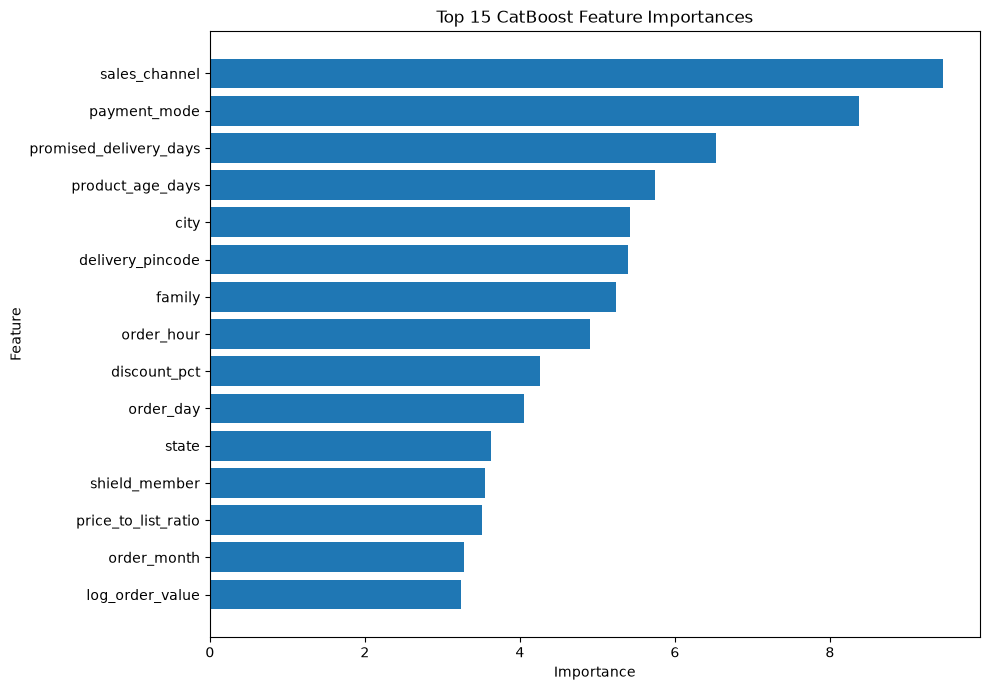

In [99]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "Importances"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature Id"],
    top_features["Importances"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 CatBoost Feature Importances")

plt.tight_layout()

plt.savefig(
    "outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
from pathlib import Path

# Project root ke relative outputs folder
output_dir = Path.cwd() / "outputs"

# Folder create karo
output_dir.mkdir(parents=True, exist_ok=True)

# Predictions save karo
predictions.to_csv(
    output_dir / "predictions.csv",
    index=False
)

print("Saved at:", output_dir / "predictions.csv")
print("Exists:", (output_dir / "predictions.csv").exists())

Saved at: c:\Users\Riyansh Jain\OneDrive\Desktop\kestrel-home-returns-risk\notebooks\outputs\predictions.csv
Exists: True


In [101]:
feature_importance.to_csv(
    output_dir / "feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.
